# Build school district polygons

This notebook creates approximate school district polygons from cleaned address points.

The address points are grouped by school districts, and a convex hull is created for each district.

These polygons will later be used for spatial analysis and for checking which schools fall inside which district.

## Load the libraries needed for this step

Here we import the libraries needed to load spatial layers, create district polygons and make quick map plots.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

## Load the cleaned address points

Here we load the cleaned address layer from the GeoPackage created in the notebook "01_prepare_datasets".

These address points will be grouped by school district and used to create convex hull polygons.

In [2]:
addresses = gpd.read_file("../data/processed/core_layers.gpkg", layer="district_addresses")
addresses.head()

,Adresse,Vejnavn,Husnummer,Postnr,Bydelsnavn,Skoledistriktsnr,Skoledistriktsnavn,GIS_koor_X,GIS_koor_Y,geometry
0,A-Vej 13,A-Vej,13,2300,Amager Øst,281053,Nordøstamager Skole,728901.86,6176142.36,POINT (728901.860 6176142.360)
1,A.C. Meyers Vænge 1,A.C. Meyers Vænge,1,2450,Vesterbro-Kongens Enghave,281060,Sluseholmen Skole,722956.55,6173122.88,POINT (722956.550 6173122.880)
2,A.C. Meyers Vænge 2,A.C. Meyers Vænge,2,2450,Vesterbro-Kongens Enghave,281060,Sluseholmen Skole,722940.54,6173165.25,POINT (722940.540 6173165.250)
3,A.C. Meyers Vænge 3,A.C. Meyers Vænge,3,2450,Vesterbro-Kongens Enghave,281060,Sluseholmen Skole,722950.72,6173111.30,POINT (722950.720 6173111.300)
4,A.C. Meyers Vænge 4,A.C. Meyers Vænge,4,2450,Vesterbro-Kongens Enghave,281060,Sluseholmen Skole,722928.31,6173172.15,POINT (722928.310 6173172.150)


## Quick check bíf the loaded address layer

Before building polygons we check that:
- The coordinate reference system
- the number of rows
- the key district columns

We do this to confirm that the correct cleaned layer has been loaded.

In [3]:
addresses.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Belgium; Denmark - onshore and offshore; Germany - onshore and offshore; Norway including - onshore and offshore; Spain - offshore.
- bounds: (6.0, 38.76, 12.01, 84.33)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [4]:
addresses.shape

(85051, 10)

In [5]:
addresses[["Skoledistriktsnr", "Skoledistriktsnavn"]].head()

,Skoledistriktsnr,Skoledistriktsnavn
0,281053,Nordøstamager Skole
1,281060,Sluseholmen Skole
2,281060,Sluseholmen Skole
3,281060,Sluseholmen Skole
4,281060,Sluseholmen Skole


## Check that each district number mathces one district name

Before grouping the data, we check whether each school district number corresponds to exactly one school district name.

This is important so that district polygons are built consistently.

In [6]:
addresses.groupby("Skoledistriktsnr")["Skoledistriktsnavn"].nunique().value_counts()

Skoledistriktsnavn
1    57
Name: count, dtype: int64

## Create convex hull polygons for each school district

Here we group the address points by school district and create one convex hull polygon for each group.

This gives an approximate boundary around all addresses belonging to the same school district.

In [7]:
districts = (
    addresses.groupby(["Skoledistriktsnr", "Skoledistriktsnavn"])["geometry"]
    .apply(lambda x: x.unary_union.convex_hull)
    .reset_index()
)

## Convert the district polygons to a GeoDataFrame

After creating the convex hull geometries, we convert the result into a proper GeoDataFrame so it can be plotted and saved and used in later spatial analysis.

In [8]:
districts = gpd.GeoDataFrame(districts, geometry="geometry", crs=addresses.crs)
districts.head()

,Skoledistriktsnr,Skoledistriktsnavn,geometry
0,101001,Den Classenske Legatskole,"POLYGON ((724736.090 6174904.010, 723736.310 6..."
1,101003,Nyboder Skole,"POLYGON ((725921.910 6176247.480, 725867.480 6..."
2,101005,Sølvgades Skole,"POLYGON ((725064.220 6176173.990, 723743.560 6..."
3,101007,Nørrebro Park Skole,"POLYGON ((723166.310 6176788.020, 723060.970 6..."
4,101008,Blågård Skole,"POLYGON ((723462.490 6176391.490, 723444.310 6..."


## Check the number of generated district polygons

Since the address dataset contained 57 school districts, we expect to get 57 polygons here as well.

In [9]:
districts.shape

(57, 3)

In [10]:
districts["Skoledistriktsnr"].nunique()

57

## Plot the district polygons

Here we make a first quick map of the convex hull polygons to see whether they look reasonable and cover the expected parts of Copenhagen.

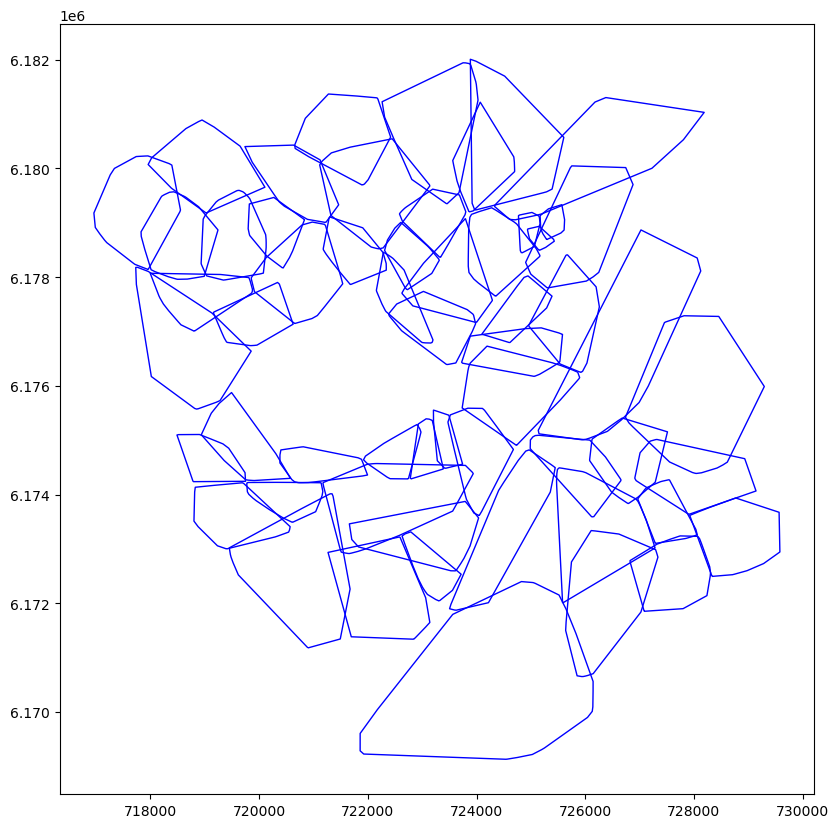

In [11]:
districts.plot(figsize=(10, 10), edgecolor="blue", facecolor="none")
plt.show()

## Compare the hull polygons with the original address points

This map helps check whether each convex hull polygon actaully wraps around the address points that belong to the district.

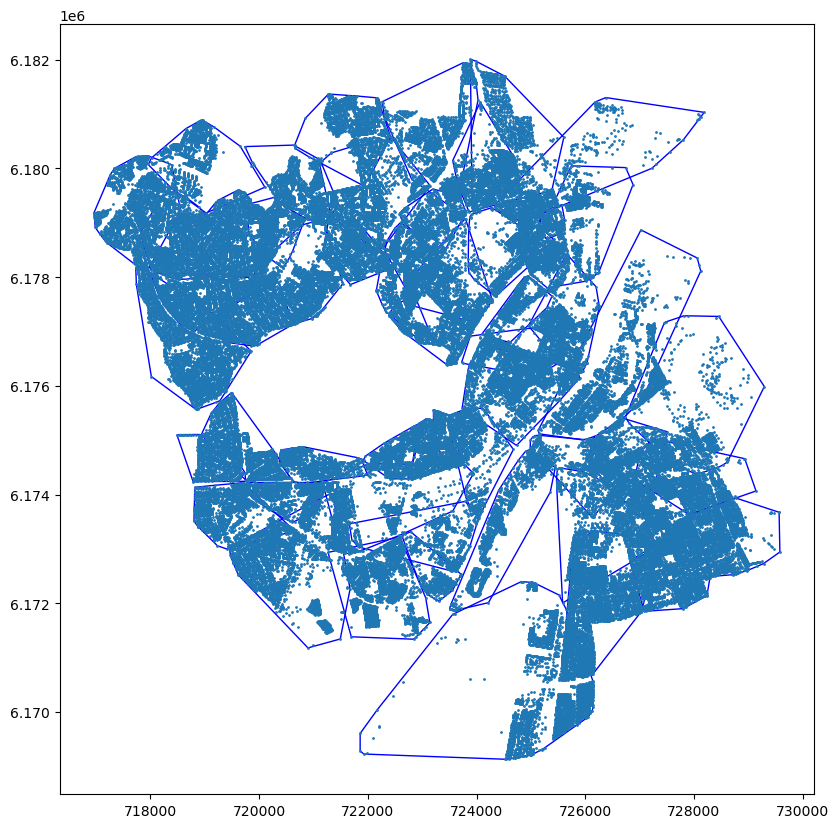

In [12]:
ax = districts.plot(figsize=(10, 10), edgecolor="blue", facecolor="none")
addresses.plot(ax=ax, markersize=1)
plt.show()

## Load the cleaned school locations

Here we load the school points so we can compare them with the district polygons and later check which school lies inside which district

In [13]:
schools = gpd.read_file("../data/processed/core_layers.gpkg", layer="schools")
schools.head()

,school_name,school_type,geometry
0,Den Classenske Legatskole,district_school,POINT (724837.610 6175474.080)
1,Nyboder Skole,district_school,POINT (725396.320 6177471.680)
2,Sølvgades Skole,district_school,POINT (725231.150 6177008.350)
3,Nørrebro Park Skole,district_school,POINT (722788.310 6177305.740)
4,Blågård Skole,district_school,POINT (723187.390 6176996.040)


## Make sure the school points use the same CRS

Before plotting and joining lauers together, we make sure the school points and district polygons use the same coordinate reference system

In [14]:
schools.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Belgium; Denmark - onshore and offshore; Germany - onshore and offshore; Norway including - onshore and offshore; Spain - offshore.
- bounds: (6.0, 38.76, 12.01, 84.33)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## Plot schools together with district polygons

This gives a first visual overview of schools and approximate school districts in the same map

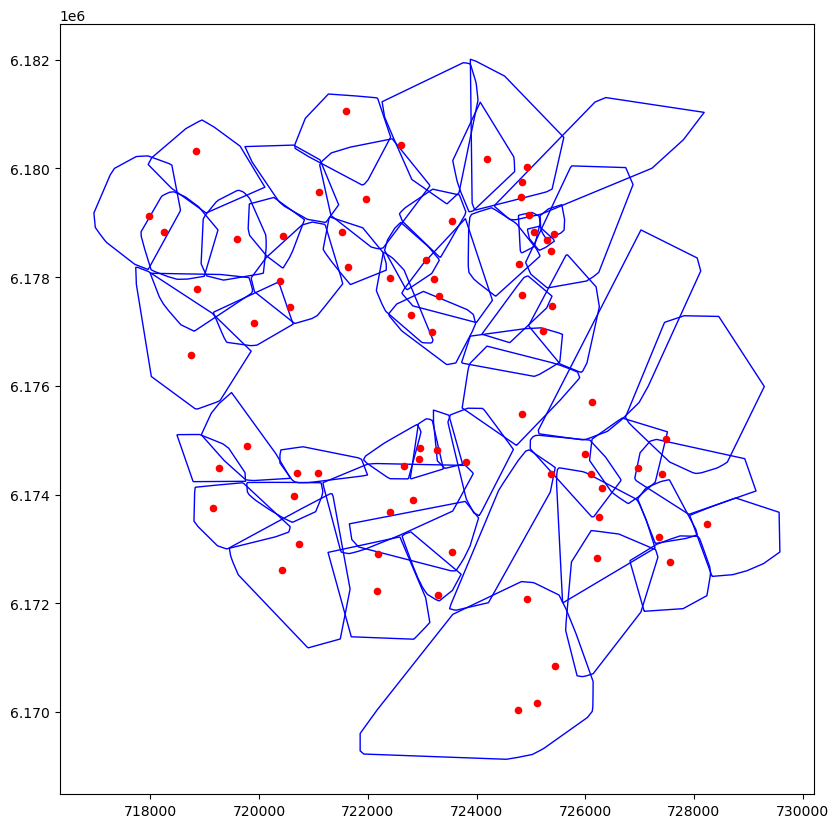

In [15]:
ax = districts.plot(figsize=(10, 10), edgecolor="blue", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)
plt.show()